# Category and Subcategory vs. Campaign Success

## Objective

This analysis explores how Kickstarter campaign success rates vary across campaign categories and subcategories.

The analysis will:
- Calculate the success rate for each campaign category
- Calculate the success rate for each campaign subcategory
- Identify categories and subcategories with higher and lower observed success rates
- Visualize success rates using ranked bar charts
- Document key findings for future feature selection and modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import html

In [2]:
# Load the dataset
df = pd.read_csv("../data/kickstarter_us_filtered.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (38504, 17)


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
3,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00
4,316217,Dinner Party - a short film about friendship.....,http://www.kickstarter.com/projects/249354515/...,Film & Video,Short Film,"Portland, OR",successful,3500.0,3582.0,1.023331,39,"Wed, 22 Jun 2011 13:33:00 -0000",7,"$5,$25,$50,$100,$250,$500,$1,000",8,0,21.43


## Inspect Category and Subcategory Data

In [3]:
# Check for missing values, data type, cardinality, and campaign counts
print("Missing category values:", df["category"].isnull().sum())
print("Missing subcategory values:", df["subcategory"].isnull().sum())

print("\nCategory data type:", df["category"].dtype)
print("Subcategory data type:", df["subcategory"].dtype)

print("\nUnique categories:", df["category"].nunique())
print("Unique subcategories:", df["subcategory"].nunique())

print("\nCampaigns by category:")
print(df["category"].value_counts())
print("\nCampaigns by subcategory:")
print(df["subcategory"].value_counts())

Missing category values: 0
Missing subcategory values: 0

Category data type: str
Subcategory data type: str

Unique categories: 14
Unique subcategories: 51

Campaigns by category:
category
Film &amp; Video    10925
Music                9564
Publishing           3779
Art                  3259
Theater              2201
Design               1452
Games                1365
Food                 1243
Photography          1110
Fashion               975
Comics                915
Technology            656
Dance                 650
Film & Video          410
Name: count, dtype: int64

Campaigns by subcategory:
subcategory
Short Film                3519
Documentary               3056
Music                     2878
Theater                   2201
Film &amp; Video          2162
Indie Rock                1733
Rock                      1585
Narrative Film            1294
Food                      1243
Photography               1110
Fashion                    975
Webseries                  960
Comics   

### Normalize Category Labels

The initial inspection identified HTML-encoded versions of some category and subcategory labels. These labels are normalized before calculating success rates so equivalent groups are analyzed together.

In [4]:
df["category"] = df["category"].apply(html.unescape).str.strip()
df["subcategory"] = df["subcategory"].apply(html.unescape).str.strip()

# Validate
print("Unique categories after normalization:", df["category"].nunique())
print("Unique subcategories after normalization:", df["subcategory"].nunique())

Unique categories after normalization: 13
Unique subcategories after normalization: 49


## Success Rate by Category

Calculate the number of campaigns and observed success rate for each campaign category, then rank the categories by success rate.

In [5]:
category_summary = (
    df.groupby("category")
    .agg(
        total_campaigns=("status", "size"),
        successful_campaigns=("status", lambda x: (x == "successful").sum())
    )
)

category_summary["success_rate"] = (
    category_summary["successful_campaigns"] / category_summary["total_campaigns"] * 100
)

category_summary = category_summary.sort_values(
    "success_rate", 
    ascending=False
)

category_summary.round(2)

,total_campaigns,successful_campaigns,success_rate
category,,,
Dance,650,495,76.15
Theater,2201,1551,70.47
Music,9564,6484,67.80
Art,3259,1841,56.49
Comics,915,495,54.10
Film & Video,11335,5786,51.05
Food,1243,627,50.44
Design,1452,668,46.01
Photography,1110,483,43.51


## Category Success Rate Visualization

Visualize campaign categories ranked by observed success rate.

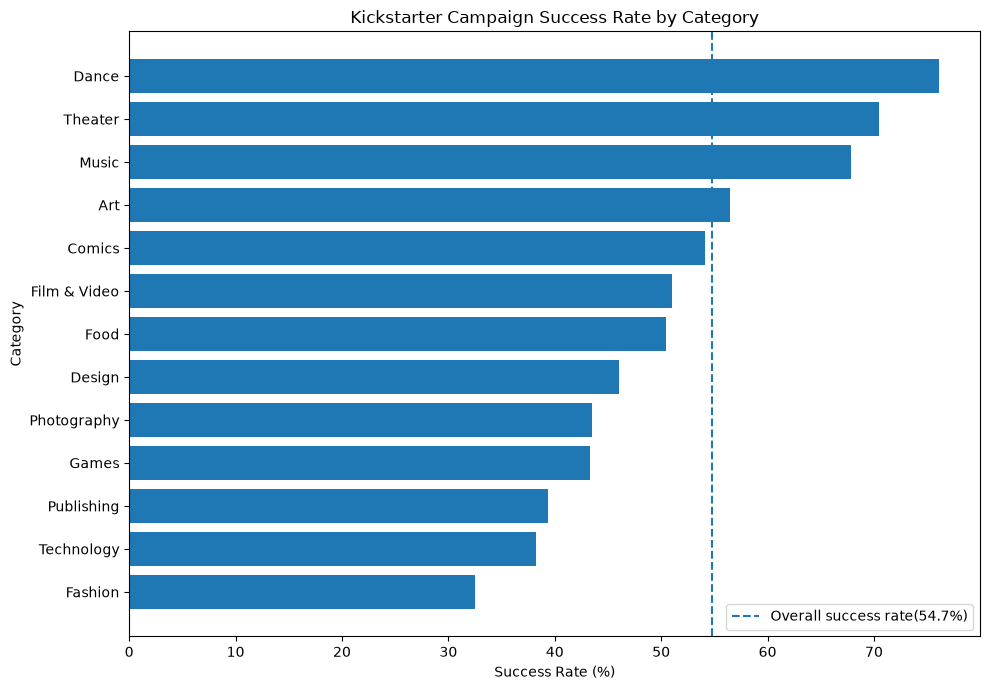

In [6]:
# Sort categories by success rate for visualization
category_plot = category_summary.sort_values("success_rate")

overall_success_rate = (
    (df["status"] == "successful").mean() * 100
)

plt.figure(figsize=(10, 7))

plt.barh(
    category_plot.index,
    category_plot["success_rate"]
)

plt.axvline(
    overall_success_rate,
    linestyle="--",
    label=f"Overall success rate({overall_success_rate:.1f}%)"
)

plt.xlabel("Success Rate (%)")
plt.ylabel("Category")
plt.title("Kickstarter Campaign Success Rate by Category")
plt.legend()

plt.tight_layout()
plt.show()

## Success Rate by Subcategory

Calculate the number of campaigns and observed success rate for each campaign subcategory, then rank the subcategories by success rate.

In [7]:
subcategory_summary = (
    df.groupby("subcategory")
    .agg(
        total_campaigns=("status", "size"),
        successful_campaigns=("status", lambda x: (x == "successful").sum())
    )
)

subcategory_summary["success_rate"] = (
    subcategory_summary["successful_campaigns"]
    / subcategory_summary["total_campaigns"]
    * 100
)

subcategory_summary = subcategory_summary.sort_values(
    "success_rate",
    ascending=False
)

subcategory_summary.round(2)

,total_campaigns,successful_campaigns,success_rate
subcategory,,,
Dance,650,495,76.15
Indie Rock,1733,1307,75.42
Classical Music,394,294,74.62
Country & Folk,942,702,74.52
Jazz,383,278,72.58
Theater,2201,1551,70.47
Rock,1585,1087,68.58
Pop,659,438,66.46
Public Art,473,309,65.33


In [8]:
# Inspect subcategory sample sizes
subcategory_summary["total_campaigns"].describe()

count      49.000000
mean      785.795918
std       791.203618
min       119.000000
25%       272.000000
50%       450.000000
75%       942.000000
max      3519.000000
Name: total_campaigns, dtype: float64

In [9]:
# Inspect smallest subcategories by total campaigns
subcategory_summary.sort_values("total_campaigns").head(20)

,total_campaigns,successful_campaigns,success_rate
subcategory,,,
Digital Art,119,55,46.218487
Conceptual Art,138,79,57.246377
Open Hardware,153,87,56.862745
Graphic Design,155,93,60.000000
Illustration,171,102,59.649123
Poetry,192,84,43.750000
Open Software,198,56,28.282828
Crafts,217,99,45.622120
Games,227,129,56.828194


In [10]:
# Inspect largest subcategories by total campaigns
subcategory_summary.sort_values(
    "total_campaigns",
    ascending=False
).head(20)

,total_campaigns,successful_campaigns,success_rate
subcategory,,,
Short Film,3519,2166,61.551577
Documentary,3056,1479,48.396597
Music,2878,1872,65.045170
Theater,2201,1551,70.467969
Film & Video,2162,970,44.865865
Indie Rock,1733,1307,75.418350
Rock,1585,1087,68.580442
Narrative Film,1294,642,49.613601
Food,1243,627,50.442478


## Minimum Sample Size for Subcategories 

To reduce the influence of smaller and less stable samples, only subcategories with at least 300 campaigns are included in the ranked success-rate comparison.

In [11]:
subcategory_filtered = subcategory_summary[
    subcategory_summary["total_campaigns"] >= 300].copy()

print("Subcategories included:", len(subcategory_filtered))
print("Subcategories excluded:", len(subcategory_summary) - len(subcategory_filtered))

subcategory_filtered.round(2)

Subcategories included: 35
Subcategories excluded: 14


,total_campaigns,successful_campaigns,success_rate
subcategory,,,
Dance,650,495,76.15
Indie Rock,1733,1307,75.42
Classical Music,394,294,74.62
Country & Folk,942,702,74.52
Jazz,383,278,72.58
Theater,2201,1551,70.47
Rock,1585,1087,68.58
Pop,659,438,66.46
Public Art,473,309,65.33


## Subcategory Success Rate Visualization

Visualize campaign subcategories ranked by observed success rate.

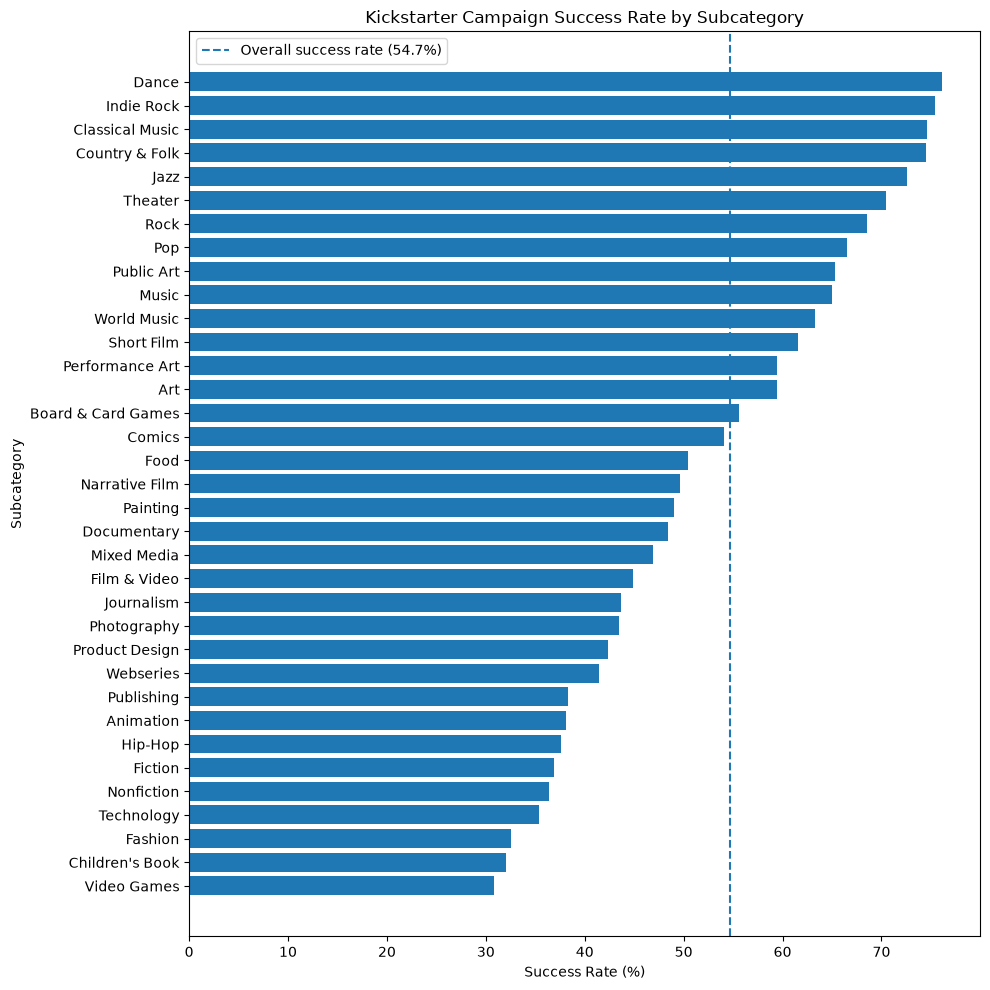

In [12]:
# Sort subcategories by success rate for visualization
subcategory_plot = subcategory_filtered.sort_values("success_rate")

overall_success_rate = (
    (df["status"] == "successful").mean() * 100
)

plt.figure(figsize=(10, 10))

plt.barh(
    subcategory_plot.index,
    subcategory_plot["success_rate"]
)

plt.axvline(
    overall_success_rate,
    linestyle="--",
    label=f"Overall success rate ({overall_success_rate:.1f}%)"
)

plt.xlabel("Success Rate (%)")
plt.ylabel("Subcategory")
plt.title("Kickstarter Campaign Success Rate by Subcategory")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
# Highest and lowest category success rates
print("Highest categories:")
display(category_summary.head())

print("Lowest categories:")
display(category_summary.tail())

Highest categories:


,total_campaigns,successful_campaigns,success_rate
category,,,
Dance,650,495,76.153846
Theater,2201,1551,70.467969
Music,9564,6484,67.795901
Art,3259,1841,56.489721
Comics,915,495,54.098361


Lowest categories:


,total_campaigns,successful_campaigns,success_rate
category,,,
Photography,1110,483,43.513514
Games,1365,591,43.296703
Publishing,3779,1486,39.322572
Technology,656,251,38.262195
Fashion,975,317,32.512821


In [14]:
# Highest and lowest subcategory success rates
print("Highest subcategories:")
display(subcategory_filtered.head())

print("Lowest subcategories:")
display(subcategory_filtered.tail())

Highest subcategories:


,total_campaigns,successful_campaigns,success_rate
subcategory,,,
Dance,650,495,76.153846
Indie Rock,1733,1307,75.418350
Classical Music,394,294,74.619289
Country & Folk,942,702,74.522293
Jazz,383,278,72.584856


Lowest subcategories:


,total_campaigns,successful_campaigns,success_rate
subcategory,,,
Nonfiction,789,287,36.375158
Technology,305,108,35.409836
Fashion,975,317,32.512821
Children's Book,515,165,32.038835
Video Games,688,212,30.813953


## Findings

- Campaign success rates varied considerably across categories. Dance had the highest observed category success rate at 76.15%, while Fashion had the lowest at 32.51%.
- Dance (76.15%), Theater (70.47%), Music (67.80%), and Art (56.49%) had success rates above the overall campaign success rate of approximately 54.7%.
- Among subcategories with at least 300 campaigns, Dance had the highest observed success rates at 76.15%, followed by Indie Rock (75.42%), Classical Music (74.62%), and Country & Folk (74.52%), while Video Games had the lowest at 30.81%.
- Subcategory analysis revealed additional variation that was not always visible at the broader category level. For example, the Games category had an overall success rate of 43.30%, while Board & Card Games had a success rate of 55.56% and Video Games had a success rate of 30.81%.
- Similar broad patterns appeared across the category and subcategory analyses. Music-related subcategories were frequently among the higher-success groups, while several Technology, Fashion, Publishing, and Games-related groups appeared toward the lower end of the rankings.
- The variation across both categories and subcategories suggests that these variables may provide useful information for future predictive modeling, with subcategory potentially capturing more detailed differences between campaign types.
- These results describe associations between campaign type and campaign success and should not be interpreted as evidence that a particular category or subcategory causes a campaign to succeed.